# Financial Fraud Detection

- The objective of this notebook is to showcase the usage of the [___financial-fraud-training___ container](https://catalog.ngc.nvidia.com/orgs/nvidia/teams/cugraph/containers/financial-fraud-training) and how to deploy the produced trained models on [NVIDIA Dynamo-Triton](https://catalog.ngc.nvidia.com/orgs/nvidia/containers/tritonserver).
- We use [IBM TabFormer](https://github.com/IBM/TabFormer) as an example dataset and the dataset is preprocess before model training

NOTE:
* The preprocessing code is written specifically for the TabFormer dataset and will not work with other datasets.
* Additionally, a familiarity with [Jupyter](https://docs.jupyter.org/en/latest/what_is_jupyter.html) is assumed.

# Environment Setup (Local and Brev)
This Notebook is designed to work in both a ___Local___ and ___Brev___ environment.  However, there are a few slight differences that will be pointed out. 

### For Local Environment Setup
Please create a Conda environment and add that to the notebook - See the [README](../README.md) file

In [1]:
# default host for local run
HOST = "0.0.0.0"
BREV = False

In [2]:
BREV = True

-----
## Import libraries (both environments)

In [3]:
import os
import sys
import json
import time

### Define python function to print directory tree

In [5]:
def print_tree(directory, prefix=""):
    """Recursively prints the directory tree starting at 'directory'."""
    # Retrieve a sorted list of entries in the directory
    entries = sorted(os.listdir(directory))
    entries_count = len(entries)
    
    for index, entry in enumerate(entries):
        path = os.path.join(directory, entry)
        # Determine the branch connector
        if index == entries_count - 1:
            connector = "└── "
            extension = "    "
        else:
            connector = "├── "
            extension = "│   "
        
        print(prefix + connector + entry)
        
        # If the entry is a directory, recursively print its contents
        if os.path.isdir(path):
            print_tree(path, prefix + extension)

In [ ]:
# Check if the raw data has been placed properly
data_root_dir = "/models"
print_tree(data_root_dir)

├── gnn
│   ├── edges
│   │   └── node_to_node.csv
│   ├── nodes
│   │   ├── node.csv
│   │   ├── node_label.csv
│   │   └── offset_range_of_training_node.json
│   └── test_gnn
│       ├── edges
│       │   └── node_to_node.csv
│       └── nodes
│           ├── node.csv
│           └── node_label.csv
├── raw
│   ├── card_transaction.v1.csv
│   ├── readme.md
│   ├── transactions.tgz
│   └── wget-log
├── trained_models
│   ├── model_repository
│   │   ├── model
│   │   │   ├── 1
│   │   │   │   └── graph_sage_node_embedder.onnx
│   │   │   └── config.pbtxt
│   │   └── xgboost
│   │       ├── 1
│   │       │   └── xgboost_on_embeddings.json
│   │       └── config.pbtxt
│   └── python_backend_model_repository
│       └── prediction_and_shapley
│           ├── 1
│           │   ├── __pycache__
│           │   │   └── model.cpython-312.pyc
│           │   ├── embedding_based_xgboost.json
│           │   ├── model.py
│           │   └── state_dict_gnn_model.pth
│           └── config.pbtxt
└─

#### Make sure that `python_backend_model_repository` has been created with right contents
According to the training configuration file defined earlier, if the trining run successfully, a folder titled `python_backend_model_repository` containing a python backend model and a configuration file will be created under 
{model_output_dir} and its contents should look like

```sh
python_backend_model_repository/
└── prediction_and_shapley
    ├── 1
    │   ├── embedding_based_xgboost.json
    │   ├── model.py
    │   └── state_dict_gnn_model.pth
    └── config.pbtxt

```


In [ ]:
print_tree(os.path.join(model_output_dir, 'model_repository'))

----
# Step 4:  Serve your python backend model using NVIDIA Dynamo-Triton
__!Important__: Change MODEL_REPO_PATH to point to `{model_output_dir}` / `python_backend_model_repository` if you used a different path in your training configuration file

#### Install NVIDIA Dynamo-Triton Client

In [13]:
!pip install 'tritonclient[all]'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 87.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 176.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 99.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.6/607.6 kB 29.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [aiohttp]━ 13/14 [aiohttp]event]f]


In [12]:
import tritonclient.grpc as triton_grpc
import tritonclient.http as httpclient
from tritonclient import utils as triton_utils


##### Replace HOST with the actual URL where your NVIDIA Dynamo-Triton server is hosted.


In [13]:
HTTP_PORT = 8005
GRPC_PORT = 8006
METRICS_PORT = 8007

### Serve your models with NVIDIA Dynamo-Triton
- Pull the NVIDIA Dynamo-Triton docker image
- Deploy server with models and configuration files (produced by the training container)
- Double check that your `python_backend_model_repository` folder, located under `${model_output_dir}`, has the following structures
```sh
python_backend_model_repository/
└── prediction_and_shapley
    ├── 1
    │   ├── embedding_based_xgboost.json
    │   ├── model.py
    │   └── state_dict_gnn_model.pth
    └── config.pbtxt
```

### URLs for GRPC and HTTP request to the inference server

In [36]:
client_grpc = triton_grpc.InferenceServerClient(url=f'{HOST}:{GRPC_PORT}')
client_http = httpclient.InferenceServerClient(url=f'{HOST}:{HTTP_PORT}')

## Prediction without computing Shapley values

### Read preprocessed input transactions to send query to NVIDIA Dynamo-Triton

In [ ]:
import os
import pandas as pd
import numpy as np

gnn_data_dir = ""
model_name = "prediction_and_shapley"
test_X_path = os.path.join(gnn_data_dir, "test_gnn", "nodes/node.csv") # already preprocessed data
test_X = pd.read_csv(test_X_path)
X = test_X.values.astype(np.float32)

test_y_path = os.path.join(gnn_data_dir, "test_gnn", "nodes/node_label.csv") # already preprocessed data
test_y = pd.read_csv(test_y_path)
y = test_y.values.astype(np.float32)

test_ei_path = os.path.join(gnn_data_dir, "test_gnn", "edges/node_to_node.csv") 
test_ei = pd.read_csv(test_ei_path)

# tabformer_raw_file_path = os.path.join(
#         data_root_dir, "raw", "card_transaction.v1.csv"
#     )
# train_raw = pd.read_csv(tabformer_raw_file_path)

In [40]:
X.shape

(37371, 75)

In [41]:
edge_index = test_ei.values.T.astype(np.int64)
compute_shap = np.array([False], dtype=bool) 


In [24]:
test_X.columns

Index(['Card_0', 'Card_1', 'Card_2', 'Card_3', 'Card_4', 'Card_5', 'Card_6',
       'Card_7', 'Card_8', 'Card_9', 'Card_10', 'Card_11', 'Card_12',
       'Merchant_0', 'Merchant_1', 'Merchant_2', 'Merchant_3', 'Merchant_4',
       'Merchant_5', 'Merchant_6', 'Merchant_7', 'Merchant_8', 'Merchant_9',
       'Merchant_10', 'Merchant_11', 'Merchant_12', 'Merchant_13',
       'Merchant_14', 'Merchant_15', 'Merchant_16', 'MCC_0', 'MCC_1', 'MCC_2',
       'MCC_3', 'MCC_4', 'MCC_5', 'MCC_6', 'Zip_0', 'Zip_1', 'Zip_2', 'Zip_3',
       'Zip_4', 'Zip_5', 'Zip_6', 'Zip_7', 'Zip_8', 'Zip_9', 'Zip_10',
       'Zip_11', 'Zip_12', 'Zip_13', 'Zip_14', 'City_0', 'City_1', 'City_2',
       'City_3', 'City_4', 'City_5', 'City_6', 'City_7', 'City_8', 'City_9',
       'City_10', 'City_11', 'City_12', 'City_13', 'Errors_0', 'Errors_1',
       'Errors_2', 'Errors_3', 'Errors_4', 'Chip_Chip Transaction',
       'Chip_Online Transaction', 'Chip_Swipe Transaction', 'Amount'],
      dtype='object')

In [25]:
test_ei.head()

,src,dst
0,0,11568
1,1,11569
2,2,11570
3,3,11571
4,4,11572


In [26]:
test_y.head()

,Fraud
0,0
1,0
2,0
3,0
4,0


### Evaluate performance for a batch of transactions

In [28]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


In [29]:
# Decision threshold to flag a transaction as fraud
#Change to trade-off precision and recall
decision_threshold = 0.5

In [ ]:

def compute_score_for_batch(edge_idx, X, y, batch_size, decision_threshold = 0.5, shap=False, feature_mask=None):
    edge_index = edge_idx.T.astype(np.int64)
    compute_shap = np.array([shap], dtype=bool) # Skip Shapley value computation
    
    with httpclient.InferenceServerClient(f"{HOST}:{HTTP_PORT}") as client:
        input_features = httpclient.InferInput("NODE_FEATURES", X.shape, datatype="FP32")
        input_features.set_data_from_numpy(X)

        input_edge_indices = httpclient.InferInput("EDGE_INDEX", edge_index.shape, datatype="INT64")
        input_edge_indices.set_data_from_numpy(edge_index)

        # Even though Shapley values are not requested, it still requires a feature mask.
        # It can be a dummy array of int values, but the length must be same as number of features.

        if shap:
            assert X.shape[1] == len(feature_mask)
            feature_mask = np.array(feature_mask).astype(np.int32)
        else:
            feature_mask = np.zeros(X.shape[1]).astype(np.int32)

        input_feature_mask = httpclient.InferInput("FEATURE_MASK", feature_mask.shape, datatype="INT32")
        input_feature_mask.set_data_from_numpy(feature_mask)

        compute_shap_flag = httpclient.InferInput("COMPUTE_SHAP", compute_shap.shape, datatype="BOOL")
        compute_shap_flag.set_data_from_numpy(compute_shap)
        
        outputs = [
            httpclient.InferRequestedOutput("PREDICTION"),
            httpclient.InferRequestedOutput("SHAP_VALUES")
        ]

        # Send query to the server
        response = client.infer(
            model_name,
            inputs=[input_features, input_edge_indices, compute_shap_flag, input_feature_mask],
            request_id=str(1),
            outputs=outputs,
            timeout= 3000
            )
        
    predictions = response.as_numpy('PREDICTION')

    assert y.sum() == y[-batch_size:].sum()
    if shap == False:
        y_pred = (predictions > decision_threshold).astype(int)
        
        # Compute evaluation metrics
        accuracy = accuracy_score(y[-batch_size:], y_pred[-batch_size:])
        precision = precision_score(y[-batch_size:], y_pred[-batch_size:], zero_division=0)
        recall = recall_score(y[-batch_size:], y_pred[-batch_size:], zero_division=0)
        f1 = f1_score(y[-batch_size:], y_pred[-batch_size:], zero_division=0)



        classes = ['Non-Fraud', 'Fraud']
        columns = pd.MultiIndex.from_product([["Predicted"], classes])
        index = pd.MultiIndex.from_product([["Actual"], classes])

        conf_mat = confusion_matrix(y[-batch_size:], y_pred[-batch_size:])
        cm_df = pd.DataFrame(conf_mat, index=index, columns=columns)
        print(cm_df)

        # Plot the confusion matrix directly from predictions
        disp = ConfusionMatrixDisplay.from_predictions(
            y[-batch_size:], y_pred[-batch_size:], display_labels=classes)
        disp.ax_.set_title('Confusion Matrix')
        plt.show()

        print("----Summary---")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")

    return predictions, response.as_numpy('SHAP_VALUES') if shap else None


#### Sample a batch of transactions from the test data

In [31]:
# NOTE:
# In the preprocessing code, zero-based user node indices come first, 
# followed by merchant node indices, and then transaction node indices.

# Each transaction is represented by four edges,
    # user to transaction,
    # transaction to merchant,
    # transaction to user
    # merchant to transaction

# Each transaction involves three nodes - an user, a transaction and a merchant


NR_TX =  test_ei.shape[0]//4
batch_size = NR_TX

transaction_batch = np.random.choice(NR_TX, size=batch_size, replace=False)
idx_of_edges = transaction_batch.reshape(-1, 1) + np.arange(4)*NR_TX
edges_batch = test_ei.iloc[idx_of_edges.ravel()]
unique_vertices, renumbered_edges =  np.unique(edges_batch.values, return_inverse=True)
eidx = renumbered_edges.reshape(edges_batch.shape)

In [32]:
assert y[unique_vertices][-batch_size:].sum() == y[unique_vertices].sum()
y[unique_vertices][-batch_size:].sum(), y[unique_vertices].sum()

(2087.0, 2087.0)

                 Predicted      
                 Non-Fraud Fraud
Actual Non-Fraud     23608   108
       Fraud            75  2012


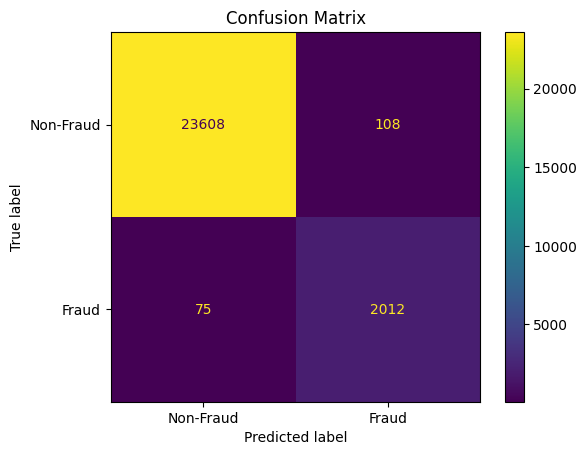

----Summary---
Accuracy: 0.9929
Precision: 0.9491
Recall: 0.9641
F1 Score: 0.9565


In [33]:
predictions, _ = compute_score_for_batch(eidx, X[unique_vertices], y[unique_vertices], batch_size=batch_size)

### Compute Shapley values of different features for a transaction
NOTE: Shapely computation is very expensive

In [ ]:
features = list(test_X.columns)
mask_mapping = {}
feature_mask = []
current_group_id = 0
prv_label = ""
for f in features:
    label = f.split("_")[0]
    
    # print(label, prv_label)
    if label!=prv_label:
        current_group_id+=1
    feature_mask.append(current_group_id)
    mask_mapping[label]=current_group_id
    prv_label = label

In [ ]:
NR_TX =  test_ei.shape[0]//4
batch_size = 1 

transaction_batch = np.random.choice(NR_TX, size=batch_size, replace=False)
idx_of_edges = transaction_batch.reshape(-1, 1) + np.arange(4)*NR_TX

edges_batch = test_ei.iloc[idx_of_edges.ravel()]
unique_vertices, renumbered_edges =  np.unique(edges_batch.values, return_inverse=True)

predictions, shap_values = compute_score_for_batch(renumbered_edges.reshape(edges_batch.shape), X[unique_vertices], y[unique_vertices], batch_size=batch_size, shap=True, feature_mask=feature_mask)

In [ ]:
feature_to_attribution_map = dict(zip(feature_mask, shap_values[2]))
feature_name_to_id_map = {v:k for k, v in mask_mapping.items()}

In [ ]:
{feature_name_to_id_map[k]: f"{v:.3f}" for k, v in feature_to_attribution_map.items()}